In [51]:
import torch
import torch.nn as nn

In [52]:
N = 10**2
X = torch.linspace(-torch.pi,torch.pi,N).unsqueeze(1)
Y = torch.sin(X)

In [57]:
def Net():
    torch.manual_seed(0)
    Phi = nn.Sequential(
        nn.Linear(1,20),
        nn.Tanh(),
        nn.Linear(20,1)
    )
    return Phi

def train_standard(X,Y,epochs,eta,bs,model,type="std",sigma=0.1):
    opt = torch.optim.SGD(lr=eta,params=model.parameters())
    lossFn = nn.MSELoss()
    N = X.shape[0]
    Lh = []
    for e in range(1,epochs+1):
        order = torch.randperm(N)
        Lhe = 0
        for b in range(0,N,bs):
            opt.zero_grad()
            L = 0
            bsL = len(order[b:b+bs])
            for i in order[b:b+bs]:
                pred = model(X[i])
                L+= lossFn(Y[i],pred)
            L=L/bsL
            L.backward()
            if type=="std":
                opt.step()
            elif type=="L":
                with torch.no_grad():
                    for p in model.parameters():
                        p+=-eta*p.grad+sigma*torch.randn(1)
            Lhe += L.item()
        Lh.append(Lhe)
    return Lh

In [61]:
M1 = Net()
M2 = Net()
M3 = Net()
M4 = Net()

Lhe1 = train_standard(X,Y,100,0.001,N,M1)
Lhe2 = train_standard(X,Y,100,0.001,1,M2)
Lhe3 = train_standard(X,Y,100,0.001,32,M3)
Lhe4 = train_standard(X,Y,100,0.001,N,M4,type="L")




In [62]:
import matplotlib.pyplot as plt

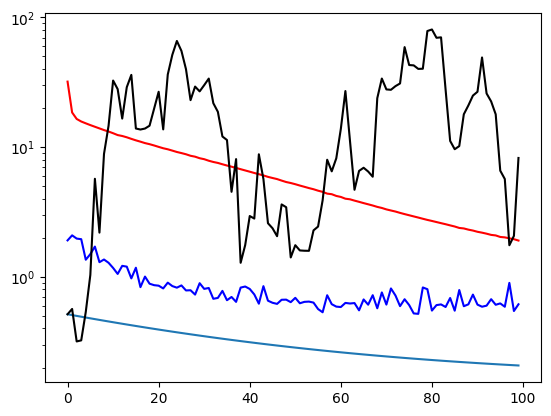

In [63]:
plt.plot(Lhe1)
plt.plot(Lhe2,color="red")
plt.plot(Lhe3,color="blue")
plt.plot(Lhe4,color="black")

plt.yscale("log")
plt.show()